Classification , target : Late_delivery_risk

# Task 1: Import Necessary Libraries

In [3]:
# Task 1: Import Necessary Libraries
import pandas as pd                    # pandas: tabular data loading/manipulation (DataFrame)
import numpy as np                     # numpy: numerical arrays, math utilities

from sklearn.model_selection import train_test_split      # splits data into train/test sets
from sklearn.preprocessing import StandardScaler          # standardizes features (mean=0, std=1) for distance-based models
from sklearn.neighbors import KNeighborsClassifier        # KNN classifier implementation

from sklearn.metrics import (                             # evaluation metrics/utilities
    accuracy_score, precision_score, recall_score, f1_score,  # scalar metrics for classification
    ConfusionMatrixDisplay                                   # helper to plot confusion matrix
)

import matplotlib.pyplot as plt         # plotting library for charts/figures


In [4]:
!pip install py7zr

import py7zr

archive_path = '/content/DataCoSupplyChainDataset_Cleaned.7z'  # updated file name
extract_path = '/content/DataCoSupplyChainDataset_Cleaned'      # folder to extract files

with py7zr.SevenZipFile(archive_path, mode='r') as z:
    z.extractall(path=extract_path)

print("Extraction completed!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.0/97.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.7/51.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.7/142.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.6/413.6 kB 8.3 MB/s eta 0:00:00
Extraction completed!


# Task 2: Load and Explore the Cleaned Dataset

In [5]:

import pandas as pd





# Task 2: Load and Explore the Cleaned Dataset
# Load processed dataset (created by Notebook 01)
csv_path = '/content/DataCoSupplyChainDataset_Cleaned/DataCoSupplyChainDataset_Cleaned.csv'
data = pd.read_csv(csv_path, encoding='latin1')      # read the single cleaned CSV produced earlier
print(f"[INFO] Loaded processed dataset → {data.shape[0]:,} rows, {data.shape[1]} cols")  # print row/column counts

# Preview
display(data.head())                    # show the first 5 rows (Jupyter display) to sanity-check columns/values

# Target quick check (class balance)
if "Late_delivery_risk" not in data.columns:              # ensure the label column exists
    raise KeyError("Column 'Late_delivery_risk' not found. Please re-check Notebook 01 export.")  # fail early if missing

print("\nLate_delivery_risk value counts:")               # header for class counts
display(data["Late_delivery_risk"].value_counts())        # print counts per class (e.g., 0 vs 1) to see imbalance


[INFO] Loaded processed dataset → 180,519 rows, 168 cols


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Department Id,Latitude,Longitude,Order Item Cardprod Id,Order Item Discount,...,Order Status_COMPLETE,Order Status_ON_HOLD,Order Status_PAYMENT_REVIEW,Order Status_PENDING,Order Status_PENDING_PAYMENT,Order Status_PROCESSING,Order Status_SUSPECTED_FRAUD,Shipping Mode_Same Day,Shipping Mode_Second Class,Shipping Mode_Standard Class
0,3,4,91.250000,314.640015,0,2,18.251453,-66.037056,1360,13.110000,...,True,False,False,False,False,False,False,False,False,True
1,5,4,-249.089996,311.359985,1,2,18.279451,-66.037064,1360,16.389999,...,False,False,False,True,False,False,False,False,False,True
2,4,4,-247.779999,309.720001,0,2,37.292233,-121.881279,1360,18.030001,...,False,False,False,False,False,False,False,False,False,True
3,3,4,22.860001,304.809998,0,2,34.125946,-118.291016,1360,22.940001,...,True,False,False,False,False,False,False,False,False,True
4,2,4,134.210007,298.250000,0,2,18.253769,-66.037048,1360,29.500000,...,False,False,False,False,True,False,False,False,False,True



Late_delivery_risk value counts:


,count
Late_delivery_risk,
1,98977
0,81542


# Task 3: Separate Features (X) and Target (y)

In [6]:
# Task 3: Separate Features (X) and Target (y)
# Features and target
y = data["Late_delivery_risk"]            # set target vector y to the classification label

# Drop the classification target + any regression targets if present
cols_to_drop = ["Late_delivery_risk"]     # start a list of columns to remove from features
for leak_col in ["Product Price", "Order Item Total"]:  # iterate potential leakage columns (regression targets)
    if leak_col in data.columns:                         # if the column exists in this dataset
        cols_to_drop.append(leak_col)                    # mark it to be dropped to avoid target leakage

X = data.drop(columns=cols_to_drop)       # define feature matrix X by dropping the target and leakage columns

print(f"X shape: {X.shape} | y shape: {y.shape}")        # print shapes to verify dimensions


X shape: (180519, 165) | y shape: (180519,)


# Task 4: Split the Data (80% Train, 20% Test)

In [7]:
# Task 4: Split the Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(     # split into train/test subsets
    X, y,                                                # features and labels
    test_size=0.2,                                       # 20% of data goes to test set
    random_state=42,                                     # fixed seed for reproducibility
    stratify=y                                           # preserve class proportions in both splits
)

print(f"X_train size is : {X_train.shape}")              # report train-feature matrix shape
print(f"X_test size  is : {X_test.shape}")               # report test-feature matrix shape
print(f"y_train size is : {y_train.shape}")              # report train-label vector shape
print(f"y_test size  is : {y_test.shape}")               # report test-label vector shape


X_train size is : (144415, 165)
X_test size  is : (36104, 165)
y_train size is : (144415,)
y_test size  is : (36104,)


# Task 5: Apply Standardization (Scaling)

In [8]:
# Task 5: Apply Standardization (Scaling)
scaler = StandardScaler()               # create a StandardScaler instance (compute mean/std on training data)

# Fit on training set, transform both
X_train_scaled = scaler.fit_transform(X_train)   # fit scaler on X_train only (no leakage), then transform X_train
X_test_scaled  = scaler.transform(X_test)        # apply the same scaling parameters to X_test

print(f"X_train_scaled shape: {X_train_scaled.shape}")   # confirm scaled train shape (same rows, columns)
print(f"X_test_scaled shape : {X_test_scaled.shape}")    # confirm scaled test shape


X_train_scaled shape: (144415, 165)
X_test_scaled shape : (36104, 165)


# Task 6: Train a Baseline KNN Classifier (k=5)

In [9]:
# Task 6: Train a Baseline KNN Classifier (k=5)
baseline_knn = KNeighborsClassifier(n_neighbors=5)   # instantiate KNN with k=5 neighbors (baseline choice)
baseline_knn.fit(X_train_scaled, y_train)            # fit (store training features/labels for neighbor search)


KNeighborsClassifier()

# Task 7: Evaluate the Baseline Model (Accuracy, Precision, Recall, F1)

In [10]:
# Task 7: Evaluate the Baseline Model (Accuracy, Precision, Recall, F1)
y_pred_base = baseline_knn.predict(X_test_scaled)    # predict class labels on the scaled test set

accuracy = accuracy_score(y_test, y_pred_base)       # overall fraction of correct predictions
precision = precision_score(y_test, y_pred_base)     # of predicted 1's, how many are truly 1 (positive predictive value)
recall = recall_score(y_test, y_pred_base)           # of true 1's, how many did we correctly predict as 1 (sensitivity/TPR)
f1 = f1_score(y_test, y_pred_base)                   # harmonic mean of precision and recall (balance measure)

print(f"Baseline KNN (k=5) → "                       # print the baseline metrics in a single formatted line
      f"Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | "
      f"Recall: {recall:.4f} | F1-score: {f1:.4f}")


Baseline KNN (k=5) → Accuracy: 0.8833 | Precision: 0.8806 | Recall: 0.9107 | F1-score: 0.8954


# Task 8: Determine the Optimal k (Accuracy vs k)

k= 1 → Accuracy: 0.8750
k= 2 → Accuracy: 0.8460
k= 3 → Accuracy: 0.8772
k= 4 → Accuracy: 0.8704
k= 5 → Accuracy: 0.8833
k= 6 → Accuracy: 0.8800
k= 8 → Accuracy: 0.8910
k=10 → Accuracy: 0.8987
k=12 → Accuracy: 0.9049
k=14 → Accuracy: 0.9088
k=16 → Accuracy: 0.9131
k=18 → Accuracy: 0.9163
k=20 → Accuracy: 0.9198

Best k: 20 with accuracy: 0.9198


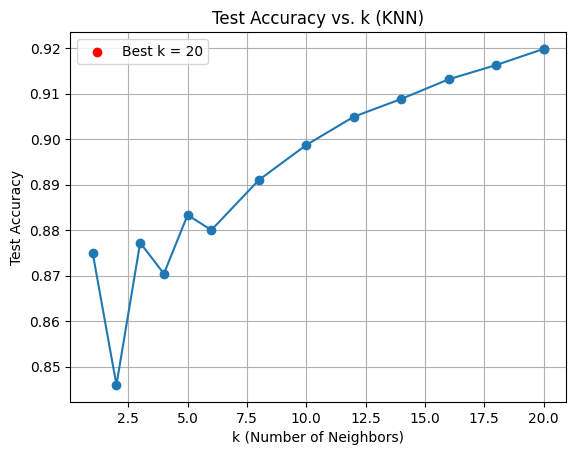

In [11]:

# Task 8: Determine the Optimal k (Accuracy vs k)
from sklearn.metrics import accuracy_score           # (re-)import accuracy_score (already imported above; harmless redundancy)
accuracy_scores = []                                 # list to collect test accuracies for each k
k_range = list(range(1, 6)) + list(range(6, 21, 2))  # define k values to test: 1..5 plus 6,8,10,...,20

for k in k_range:                                    # iterate through each candidate k
    knn = KNeighborsClassifier(n_neighbors=k)        # create a KNN with this k
    knn.fit(X_train_scaled, y_train)                 # fit on training data
    y_pred_k = knn.predict(X_test_scaled)            # predict on test data
    acc = accuracy_score(y_test, y_pred_k)           # compute test accuracy for this k
    accuracy_scores.append(acc)                      # store accuracy
    print(f"k={k:2d} → Accuracy: {acc:.4f}")         # print k and corresponding accuracy

best_k = k_range[ int(np.argmax(accuracy_scores)) ]  # choose k index with max accuracy (np.argmax), map back to actual k
best_acc = max(accuracy_scores)                      # store the best accuracy value for plotting/printing
print(f"\nBest k: {best_k} with accuracy: {best_acc:.4f}")  # report chosen k and its accuracy

# Plot Accuracy vs k (lab-style)
plt.figure()                                         # create a new figure
plt.plot(list(k_range), accuracy_scores, marker='o') # line plot of accuracy vs k with circle markers
plt.scatter(best_k, best_acc, color='red', label=f'Best k = {best_k}')  # highlight the best point in red
plt.xlabel("k (Number of Neighbors)")                # x-axis label
plt.ylabel("Test Accuracy")                          # y-axis label
plt.title("Test Accuracy vs. k (KNN)")               # plot title
plt.grid(True)                                       # show background grid for readability
plt.legend()                                         # show legend (for the red best-k marker)
plt.show()                                           # render the plot


# Task 9: Train Final KNN with Best k and Report Full Evaluation


--- Evaluation on Training Data ---
Accuracy : 0.9423
Precision: 0.9394
Recall   : 0.9564
F1-Score : 0.9479

--- Evaluation on Test Data ---
Accuracy : 0.9198
Precision: 0.9152
Recall   : 0.9409
F1-Score : 0.9279


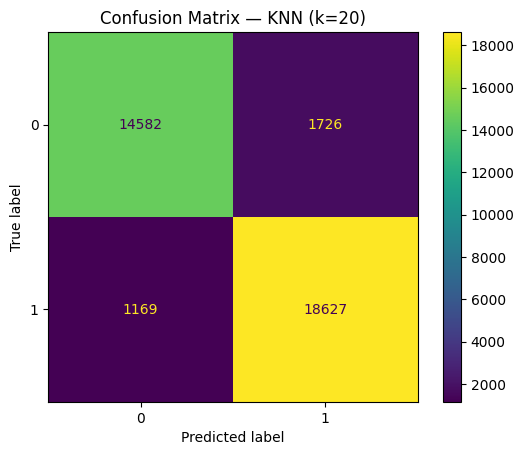

In [12]:
# Task 9: Train Final KNN with Best k and Report Full Evaluation
# Final KNN with best_k
best_knn = KNeighborsClassifier(n_neighbors=best_k)  # instantiate KNN using the selected best_k
best_knn.fit(X_train_scaled, y_train)                # fit on the training data

# Predictions
train_preds = best_knn.predict(X_train_scaled)       # predictions on training set (to check over/underfitting)
test_preds  = best_knn.predict(X_test_scaled)        # predictions on test set (final evaluation)

# --- Training metrics ---
print("\n--- Evaluation on Training Data ---")       # header for train metrics
train_accuracy = accuracy_score(y_train, train_preds)    # training accuracy
train_precision = precision_score(y_train, train_preds)  # training precision (class 1 by default)
train_recall = recall_score(y_train, train_preds)        # training recall (sensitivity)
train_f1 = f1_score(y_train, train_preds)                # training F1

print(f"Accuracy : {train_accuracy:.4f}")            # print training accuracy
print(f"Precision: {train_precision:.4f}")           # print training precision
print(f"Recall   : {train_recall:.4f}")              # print training recall
print(f"F1-Score : {train_f1:.4f}")                  # print training F1

# --- Test metrics ---
print("\n--- Evaluation on Test Data ---")           # header for test metrics
test_accuracy = accuracy_score(y_test, test_preds)       # test accuracy
test_precision = precision_score(y_test, test_preds)      # test precision
test_recall = recall_score(y_test, test_preds)            # test recall
test_f1 = f1_score(y_test, test_preds)                    # test F1

print(f"Accuracy : {test_accuracy:.4f}")             # print test accuracy
print(f"Precision: {test_precision:.4f}")            # print test precision
print(f"Recall   : {test_recall:.4f}")               # print test recall
print(f"F1-Score : {test_f1:.4f}")                   # print test F1

# --- Confusion Matrix (test) ---
ConfusionMatrixDisplay.from_predictions(y_test, test_preds)  # draw confusion matrix from true vs predicted labels
plt.title(f"Confusion Matrix — KNN (k={best_k})")            # add a descriptive title including chosen k
plt.show()                                                   # display the confusion matrix figure